### CM3/TD1 Analysis of Vibrational spectroscopy dataset 

In this activity we will exercise what we learn in the last few lectures, and notably Principal Component Analysis, to helps us analyze the EC-SERS data set. We will discuss the importance of data pre-processing, hyperparameter tunning and interpretability. 

First, lets load the data and blindly apply PCA to it, using the SVD. We will plot scores and the loadings and try to interpret them, ie. to understand what they might represent *physically*. 


A few helper functions will be defined to help you interact with data. For example,  *RunAnimation* is defined to visualize the dataset one snapshot at a time, like a movie.

In [1]:
# first, lets load the Dataset and extract the data. 
from scipy import io as io
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
%matplotlib widget

# # globally, for the whole notebook
# plt.rcParams["font.family"] = "Futura"
# plt.rcParams["font.size"] = 12


def RunAnimation(wn,X,endframe,this_yrange = [600,900]):        
    def prepanim(yrange = this_yrange,xrange=[wn[0], wn[-1]]):
        thisfig,thisax = plt.subplots(1,1,figsize = (3,3))
        thisax.set_xlim(xrange);
        thisax.set_ylim(yrange);
        thisax.set_xlabel('Wavenumber (cm-1)')
        thisax.set_ylabel('Intensity (a.u.)')  
        thisanimated_plot, = thisax.plot([],[],lw=1)
        return thisfig,thisax, thisanimated_plot   
    
    def update_plot2(frame,wn,X):
        thisanimated_plot.set_data(wn,X[frame,:])
        return thisanimated_plot,
    

    thisfig,ax, thisanimated_plot = prepanim(yrange = this_yrange,xrange = [wn[0], wn[-1]]);
    
    thisanimation = FuncAnimation(fig=thisfig, func=update_plot2,frames=endframe,fargs=(wn,X),interval=10,repeat=False)
    display(thisanimation)

    return thisanimation,thisfig,ax


1. Import the dataset using the io module. The data matrix is in a field called DM. Load it and visualize using the "Run Animation" function provided above. 

In [2]:
#EX 1:

data_path = 'data/Dataset_20190416_CV14_spectroEC2.mat'

data = io.loadmat(data_path, squeeze_me=True)
print("Here is the keys of the data dictionary: \n")
for key in data.keys():
    print(key)

Here is the keys of the data dictionary: 

__header__
__version__
__globals__
res


In [3]:
res = data['res']
print(res.dtype.names) 

DM = res['DM'].item() 
wn = res['wn'].item()

('wn', 'DM')


(<matplotlib.animation.FuncAnimation at 0x1243cf5c0>,
 <Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='Wavenumber (cm-1)', ylabel='Intensity (a.u.)'>)

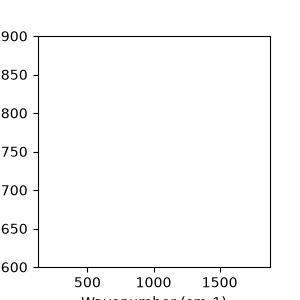

In [4]:
X = DM

RunAnimation(wn=wn, X=X, endframe=X.shape[0])

2. Lets try to directy apply PCA to the data, using the SVD decomposition as we seen in class. SVD is implemented in numpy, in the linalg module. 
In order for the data set to be meaningful, it must be centered. 
    
    2.1. We need to first center the dataset. Write a function *NormalizeFeatures* that centers every feature (column) of the dataset. 
    


In [5]:
# EX 2 : 

def NormalizeFeatures(X, axis=0):
    col_means = np.mean(X, axis=axis)
    Xn = X - col_means
    return Xn, col_means

Xn, col_means = NormalizeFeatures(X)

Xn.shape

(350, 1340)

In [6]:
# def NormFeat (X, scale = False):
#     Xn = X - np.mean(X,axis=0)
#     Col_means = np.mean(X,axis=0)
    
#     if scale:
#         Xn = Xn/np.std(Xn,axis=0)
#     return Xn

 2.2 In order to check that your routine works, write a helper function (or add an output to your function) that checks that the mean of every column is indeed 0.

In [7]:
def CheckCentered(Xn, axis=0, tol=1e-8):
    means = np.mean(Xn, axis=axis)
    ok = np.all(np.abs(means) < tol)
    print(f"Centered correctly: {ok} (max |mean| = {np.max(np.abs(means)):.2e})")
    return ok

CheckCentered(Xn)

Centered correctly: True (max |mean| = 5.72e-14)


np.True_

(<Figure size 400x200 with 2 Axes>,
 array([<Axes: title={'center': 'Original data'}>,
        <Axes: title={'center': 'Centered data'}>], dtype=object))

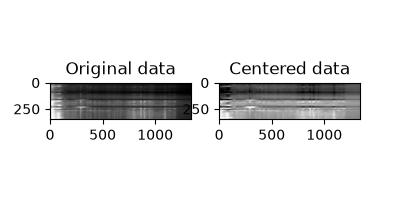

In [8]:
#Model reduit: 
def CompareDatasets(X,Xn,this_figsize = (4,2),labels = ['Data0','Data1']):
    fig3, ax = plt.subplots(1,2,figsize = this_figsize);
    ax[0].imshow(X,cmap = 'gray',vmin=np.quantile(X,0.01),vmax=np.quantile(X,0.99));
    ax[0].set_title(labels[0])
    ax[1].imshow(Xn,cmap = 'gray',aspect = 'equal',vmin=np.quantile(Xn,0.01),vmax = np.quantile(Xn,0.99));
    ax[1].set_title(labels[1])
    return fig3,ax

CompareDatasets(X,Xn,this_figsize = (4,2),labels = ['Original data','Centered data'])

3. Now that the data is centered, we can evaluate its principal components

    3.1 Compute the principal components of the dataset, using the svd. It is available in numpy, in numpy library under *numpy.linalg*. 
    
    3.2 Use the $U$, $\Sigma$ and $V^T$ matrices to build a reduced model, keeping only a few principal components. 

    3.3 Compare the centered data and the newly obtained reduced model with different number of components (using the *RunAnimation* function).What do you observe? 

In [9]:
# EX3 : TO be done²
from numpy.linalg import svd

U, S, Vt = svd(Xn)

(<matplotlib.animation.FuncAnimation at 0x16d2a8ad0>,
 <Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='Wavenumber (cm-1)', ylabel='Intensity (a.u.)'>)

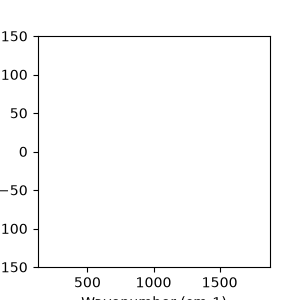

In [19]:
comp_to_keep = 3

U_reduced = U[:, :comp_to_keep]

S_reduced = np.diag(S[:comp_to_keep])

Vt_reduced = Vt[:comp_to_keep, :]

Xn_red = U_reduced @ S_reduced @ Vt_reduced

RunAnimation(wn = wn,X = Xn_red,endframe= Xn_red.shape[0],this_yrange = [-150,150])


4. On the importance of Preprocessing. 

    4.1 Did you notice something strange around $\lambda = 620 $nm? What? 

    4.2. In order to further investigate it, lets try to visualize the scores and loadings of the principal components more in detail. For that, write code to plot the normalized principal components. Observe that each PC can be plot against $\lambda$.


Text(0.5, 1.0, 'Normalized loadings of first 6 PCs')

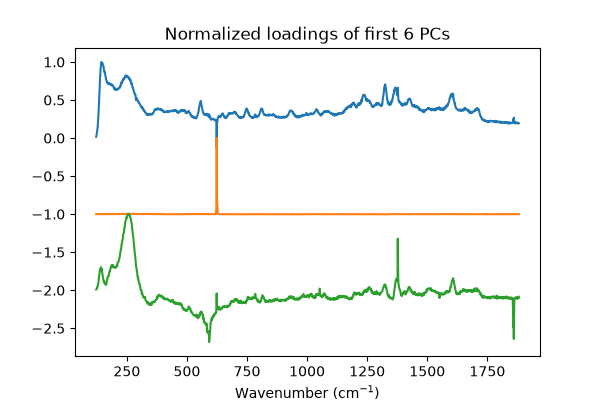

In [20]:
# EX 4 : to be done

fig, ax = plt.subplots(figsize=(6,4))

for i in range(3):
    normalized_loading = Vt[i, :] / np.max(np.abs(Vt[i, :]))
    ax.plot(wn, normalized_loading - i)
    
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
ax.set_title('Normalized loadings of first 6 PCs')


5. The following helper interative function is written to help you navigate through the decomposition. Apply it to the decomposition to explore the dataset. 

/var/folders/xz/2bjwccfj27l7jplmg_g0ppwh0000gn/T/ipykernel_4882/664959463.py:45: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect =Rectangle((XLIM[0], YLIM[0]), width=XLIM[1]-XLIM[0], height=YLIM[1]-YLIM[0], fill=True, edgecolor='red', linewidth=1,color= (1,1,1),alpha=0.8,zorder=2)


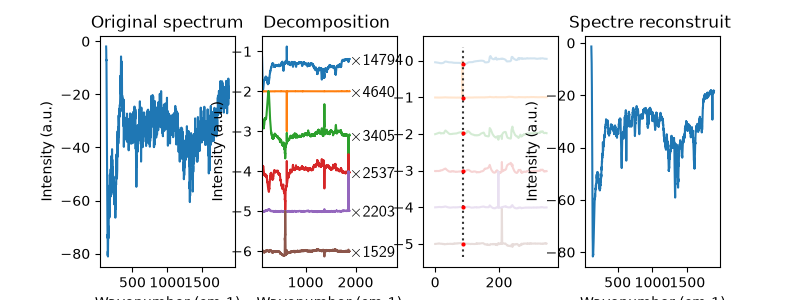

interactive(children=(IntSlider(value=86, description='thisframe', max=349), Output()), _dom_classes=('widget-…

<function __main__.updateplot(thisframe, Ncomps, U, S, Vh, Xn, line1, line2, line3, line4, line5, ax, fig)>

In [16]:
from ipywidgets import interact, interactive, fixed, interact_manual,IntSlider
import ipywidgets as widgets
from matplotlib.patches import Rectangle

def flatten(seq):
        l = []
        for elt in seq:
            t = type(elt)
            if t is tuple or t is list:
                for elt2 in flatten(elt):
                    l.append(elt2)
            else:
                l.append(elt)
        return l

def DecomposeSpectre(ax,fig,thisframe,Ncomps,U,S,Vh,Xn,wn):
    # AX0 :We plot the original spectrum
    sp = Xn[thisframe,:];
    line1, = ax[0].plot(wn,sp)
    ax[0].set_xlabel('Wavenumber (cm-1)')
    ax[0].set_ylabel('Intensity (a.u.)')
    ax[0].set_title('Original spectrum')

    # AX1 : We compute each component and plot them
    contn = 0
    for ki in Ncomps:
        contn=contn+1
        sp_comp = (U[:,ki]@np.diag(S[ki])@Vh[ki,:])[thisframe,:];
        nspect = sp_comp/np.max(np.abs(sp_comp)); 
        yy = nspect-contn 
        ax[1].plot(wn,yy)
        ax[1].text(wn[-1],yy[-1],r' $\times$'+str(round(S[ki][0])),ha='left', va='center_baseline',fontsize = 12,usetex=True)

    ax[1].set_xlabel('Wavenumber (cm-1)')
    ax[1].set_ylabel('Intensity (a.u.)')
    ax[1].set_xlim([wn[0], wn[-1]*1.5])
    ax[1].set_title('Decomposition ')
    
    allcomps = flatten(Ncomps)
        
    # AX 2 : We plot the (normalized)scores of each component in time
    for kt in Ncomps:
        line2, = ax[2].plot(U[:,kt[0]]-kt,zorder = 1);
    XLIM = ax[2].get_xlim(); YLIM = ax[2].get_ylim();
    rect =Rectangle((XLIM[0], YLIM[0]), width=XLIM[1]-XLIM[0], height=YLIM[1]-YLIM[0], fill=True, edgecolor='red', linewidth=1,color= (1,1,1),alpha=0.8,zorder=2)
    ax[2].add_patch(rect)
    line3, = ax[2].plot(thisframe*np.ones(2),YLIM,color = 'k',zorder = 3,linestyle = 'dotted',alpha = 0.8)

    cont = 0;
    cursor = np.zeros(len(Ncomps));
    for kt in Ncomps:
        cursor[cont] =U[thisframe,kt[0]]-kt[0]; 
        cont = cont+1

    line4, =ax[2].plot(thisframe*np.ones_like(cursor),cursor,zorder = 4,markersize = 3,marker = 'o',markerfacecolor = 'red',markeredgecolor = 'none',linestyle = 'None',color = 'none');

    # AX3 : We plot the reconstructed spectrum
    sp_recons = (U[:,allcomps]@np.diag(S[allcomps])@Vh[allcomps,:])[thisframe,:];
    line5, = ax[3].plot(wn,sp_recons)
    ax[3].set_xlabel('Wavenumber (cm-1)')
    ax[3].set_ylabel('Intensity (a.u.)')
    ax[3].set_title('Spectre reconstruit ')

    plt.show()
    return ax,fig, line1, line2, line3, line4, line5,

def updateplot(thisframe,Ncomps,U,S,Vh,Xn,line1,line2,line3,line4,line5,ax,fig):
    line1.set_ydata(Xn[thisframe,:]);
    ax[0].set_ylim([np.min(Xn[thisframe,:]),np.max(Xn[thisframe,:])])
    line3.set_xdata(thisframe*np.ones(2));

    cursor = np.zeros(len(Ncomps));

    cont = 0; 
    for kt in Ncomps:
        cursor[cont] =U[thisframe,kt[0]]-kt[0]; 
        cont = cont+1

    line4.set_xdata(thisframe*np.ones_like(cursor));
    line4.set_ydata(cursor);
    

    line5.set_ydata((U[:,flatten(Ncomps)]@np.diag(S[flatten(Ncomps)])@Vh[flatten(Ncomps),:])[thisframe,:]);
    #plt.subplot(144)
    ax[3].set_ylim([np.min(Xn[thisframe,:]),np.max(Xn[thisframe,:])])
    
    
    return;

Ncomps = [[0],[1],[2],[3],[4],[5]];    
thisframe = 86;
fig,ax = plt.subplots(1,4,figsize = (8,3))
ax,fig,line1,line2,line3,line4,line5 = DecomposeSpectre(ax,fig,thisframe,Ncomps,U,S,Vt,Xn,wn);

interact(updateplot,
         thisframe = IntSlider(min=0, max=Xn.shape[0]-1, step=1, value=thisframe),
         Ncomps = fixed(Ncomps),
         U = fixed(U),
         S = fixed(S),
         Vh = fixed(Vt),
         Xn = fixed(Xn),
         line1 = fixed(line1),
         line2 = fixed(line2),
         line3 = fixed(line3),
         line4 = fixed(line4),
         line5 = fixed(line5),
         ax = fixed(ax),
         fig = fixed(fig)
         )


6. It seems that weird pixels, containing sudden *spikes* that last one frame. These are *Cosmic Rays* and are a common issue in spectroscopic data.
It seems that everytime one such pixels arives, the value of PCs 2 and 5 tends to spike. 

    6.1. Verify it using the interactive applet. 
    
    6.2. Can you explain this behaviour? 

7. Lets try to improve the dataset by removing such cosmic rays. One such functions is defined below. It identifies pixels that statistically differ from its neighbours, removes them, and interpolates them using the neighbouring points. 
    
    7.1.Write a small script to check the new function. (For example a 2x1 subplot on which the first shows a spectrum, and the second the effect of *RemoveCosmic* from the spectrum)
    
    7.2.Write a function to apply it to every spectrum  

In [21]:
def RemoveCosmic(rs, threshold=5,FLAG = False, replacemethod='nan'):
   # Uses the methods described in "A simple algorithm for despiking Raman spectra' 'Chemometrics and Intelligent Laboratory Systems 179 (2018) 82–84"
   
    diff = np.diff(rs, prepend=0)  
    rs = rs.astype(float)
    # Find indices where the absolute derivative exceeds the threshold
    median_diff = np.median(np.abs(diff)).astype(float)
    MAD_diff = np.median(np.abs(diff - median_diff)).astype(float)
    Zscore = np.abs(diff - median_diff) / MAD_diff
    i_CosRay = np.where(Zscore>threshold)[0]
    
    rs[i_CosRay] = np.nan
    
    if replacemethod == 'interp':
        # Interpolate to replace NaN values
        nans, x = np.isnan(rs), lambda z: z.nonzero()[0]
        rs[nans] = np.interp(x(nans), x(~nans), rs[~nans])

    

    # Print message if cosmic rays were removed and FLAG is True
    if len(i_CosRay) > 0 and FLAG:
        print("Cosmic rays removed.")

    rs_c = rs
    return rs_c



# EX 7: to be done 

In [27]:
Xn_clean = RemoveCosmic(Xn, threshold=5, FLAG=True, replacemethod='interp')

Cosmic rays removed.


Cosmic rays removed.


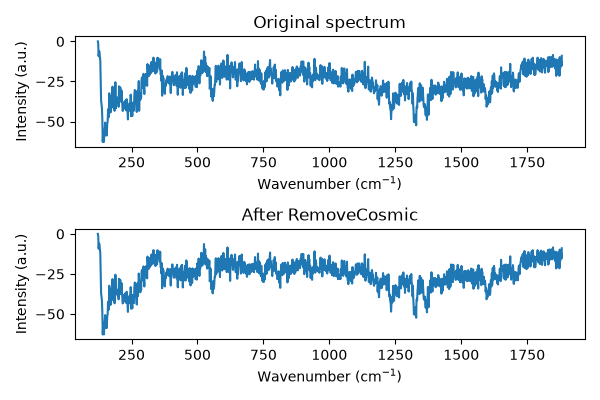

In [35]:
frame = 25  # pick a frame — ideally one you know has a cosmic ray spike
spectrum = Xn[frame, :]
cleaned = RemoveCosmic(spectrum, threshold=5, FLAG=True, replacemethod='interp')

fig, ax = plt.subplots(2, 1, figsize=(6, 4))

ax[0].plot(wn, spectrum)
ax[0].set_title('Original spectrum')
ax[0].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[0].set_ylabel('Intensity (a.u.)')

ax[1].plot(wn, cleaned)
ax[1].set_title('After RemoveCosmic')
ax[1].set_xlabel('Wavenumber (cm$^{-1}$)')
ax[1].set_ylabel('Intensity (a.u.)')

plt.tight_layout()


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(Xn, cmap='gray', vmin=np.quantile(Xn, 0.01), vmax=np.quantile(Xn, 0.99))
ax[0].set_title('Original Data')
ax[1].imshow(Xn_clean, cmap='gray', vmin=np.quantile(Xn_clean, 0.01), vmax=np.quantile(Xn_clean, 0.99))
ax[1].set_title('Cleaned Data')

8. Lets look again to the components of the transformed dataset. 
    
    8.1. What do you observe?
    
    8.2  Interpret the different components of the U and V matrices. 


In [ ]:
Xn2,col = NormalizeFeatures(X)
Xnc = ApplyRemoveCosmic(Xn2,threshold=5,FLAG = False, replacemethod='interp')

Uc,Sc,Vtc = svd(Xnc)

Ncomps = [[0],[1],[2],[3]];    
thisframe = 86;
fig10,ax10 = plt.subplots(1,4,figsize = (8,3))

ax10,fig10,line1,line2,line3,line4,line5 = DecomposeSpectre(ax10,fig10,thisframe,Ncomps,Uc,Sc,Vtc,Xnc,wn);

interact(updateplot,
         thisframe = IntSlider(min=0, max=Xn.shape[0]-1, step=1, value=thisframe),
         Ncomps = fixed(Ncomps),
         U = fixed(Uc),
         S = fixed(Sc),
         Vh = fixed(Vtc),
         Xn = fixed(Xnc),
         line1 = fixed(line1),
         line2 = fixed(line2),
         line3 = fixed(line3),
         line4 = fixed(line4),
         line5 = fixed(line5),
         ax = fixed(ax10),
         fig = fixed(fig10)
         )


In [ ]:
# Correction: 
fig,ax = plt.subplots(1,2,figsize = (6,3))
for kk in range(4):
    ax[0].plot(wn,Vtc[kk,:]/max(abs(Vtc[kk,:]))-kk)
    ax[1].plot(Uc[:,kk]/max(abs(Uc[:,kk]))-kk)




Now lets give a chemical interpreation to the eigenvectors obtained. Plotting the data against $\lambda$ allows the vectors to be interpreted as vibrationnal spectra. Lets try to take this interpretation further by looking at SERS spectra collected from the litterature and representative of species that we expect to be present. We expect that peaks from caffeine should be present, but also other phenomena, such as gold oxidation, or non specific adsorption (notably Au-Cl) bands from the electrolyte. Litterature data is included in the "sers_data_XXX.mat' files. A loader function *LoadSERS* is provided below to help you. 

 


8. Plot the 4 first eigenvectors (principal components) and associate each to chemical functions with the help of the spectral data provided (sers_data.mat). 




In [ ]:
from scipy.io import loadmat
def LoadSERS(fn):
    data = loadmat(fn)
    pos = data['position'][0]
    app = data['appreciation'][0]
    assig = data['assignment'][0]
    orig = data['origin'][0]
    doi = data['doi'][0]
    return pos, app,assig, orig,doi

In [ ]:
# To be done Ex8. 


Now we can interpret the lines of U (the scores) chemically: if several bands of caffeine are present in the PC4, then everytime PC4 has a high score, caffeine is likely to be present! (*If looks like a dog, if it barks like a dog, if it moves like a dog..... it must be a dog!!*)

9. Based on this, identify a criterium for identifying times where caffeine is likely to be dominant. 

10. Now lets load the electrochemical potentials and check what the potentials correspond to, knowing that each Raman spectrum takes 5 seconds to record, and that both experiments are started at the same time. 

In [ ]:
# To be done : EX9 

#TO be done : EX10;

ecdata = io.loadmat('EC_data.mat')

